# Homework 6 Optimization and Neural Network

## Due: 10/7


## Part 1 Conceptual Questions of Optimization 

### Q1. Plain gradient descent updates the weight using only the *current* gradient. What problem does this cause when the loss surface looks like a narrow, elongated valley (steep in one direction, flat in another)? What does momentum add to the update rule to help with this?

For the case of a narrow elongated valley, using normal gradient descent makes the optimization oscillate
sharply back and forth in the steep direction and progress slowly in the flat direction.
Momentum adds a weighted contribution from previous updates, and so since the sharp changes in the steep
direction are normally in opposite signs, it reduces these oscillations and, because the gradients
normally point in the same direction in the flat side, it builds speed in that direction.

### Q2. Momentum mainly tracks the recent **direction of the gradients**. What additional information is introduced by Adam through the squared-gradient term? Explain briefly.

Adam adds information about the magnitude of the seen gradients, not just their direction like momentum.
Because it squares the gradients

$$
v_t=\beta_2 v_{t-1}+(1-\beta_2)g_t^2
$$

This estimates how large the gradient has recently been for each parameter. It then scales the update with

$$
\Delta \propto \frac{1}{\sqrt{v_t}}
$$

So if a parameter has consistently large gradients, it reduces its step size. If its gradients are small, it allows relatively larger steps.

## Part 2 Momentum: Hand Calculation + Code Verification

In [1]:
# Import all libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

We reuse the single-neuron setup from lecture: $x=1,\; y=2,\; w_0=0.5,\; b=0$,
ReLU activation, squared loss. Instead of updating once, we now train for **3 iterations**,
assuming the gradient $\partial L/\partial w$ for weights (w) at each step turns out to be:

$$g_1 = -3.0,\quad g_2 = -1.8,\quad g_3 = -0.9$$

(These are just given to you -- you do not need to re-derive them from the loss function.)

**Momentum update rule :**

$$m_t = \beta m_{t-1} + (1-\beta)g_t \qquad w_t = w_{t-1} - \eta \, m_t$$

with $m_0 = 0$, $\beta = 0.9$, $\eta = 0.1$.

### Q3.

Compute $m_1, w_1, m_2, w_2, m_3, w_3$ by hand (on paper or in a markdown cell) before
running the code below. Fill in your hand-computed values here:


| step | m_t | w_t |
|---|---|---|
| 1 | -0.3 | 0.53 |
| 2 | -0.45 | 0.575 |
| 3 | -0.495 | 0.6245 |

In [2]:
def momentum_update(w, m, grad, lr=0.1, beta=0.9):
    m_new = beta * m + (1 - beta) * grad
    w_new = w - lr * m_new
    return w_new, m_new


w, m = 0.5, 0.0
gradients = [-3.0, -1.8, -0.9]

for t, g in enumerate(gradients, start=1):
    w, m = momentum_update(w, m, g, lr=0.1, beta=0.9)
    print(f"step {t}: m = {m:.4f}, w = {w:.4f}")

step 1: m = -0.3000, w = 0.5300
step 2: m = -0.4500, w = 0.5750
step 3: m = -0.4950, w = 0.6245


## Part 3 Adam: Hand Calculation + Code Verification

Same gradient sequence as Part 2: $g_1=-3.0,\; g_2=-1.8,\; g_3=-0.9$,
$w_0 = 0.5$, $\eta = 0.1$.

**Adam update rule:**

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t \qquad\qquad
s_t = \beta_2 s_{t-1} + (1-\beta_2) g_t^2$$

$$\hat{m}_t = \frac{m_t}{1-\beta_1^{t}} \qquad\qquad
\hat{s}_t = \frac{s_t}{1-\beta_2^{t}}$$

$$w_t = w_{t-1} - \eta \, \frac{\hat{m}_t}{\sqrt{\hat{s}_t} + \epsilon}$$

with $m_0=0,\; s_0=0,\; \beta_1=0.9,\; \beta_2=0.999,\; \epsilon=10^{-8}$.

### Q4

Compute $m_1, s_1, \hat{m}_1, \hat{s}_1, w_1$ by hand. Show your work in the
markdown cell below.


$$
m_1 = 0.9 (0) + 0.1 (-3) = -0.3
$$

$$
s_1 = 0.999 (0) + 0.001 (-3)^2 = 0.009
$$

$$
\hat m_1 = \frac{-0.3}{0.1} = -3
$$

$$
\hat s_1 = \frac{0.009}{0.001} = 9
$$

$$
w_1 = 0.5 - 0.1 \frac{-3}{\sqrt9+10^{-8}} \approx 0.6
$$

In [3]:
def adam_update(w, m, s, grad, t, lr=0.1, beta1=0.9, beta2=0.999, eps=1e-8):
    m_new = beta1 * m + (1 - beta1) * grad
    s_new = beta2 * s + (1 - beta2) * grad**2
    m_hat = m_new / (1 - beta1**t)
    s_hat = s_new / (1 - beta2**t)
    w_new = w - lr * m_hat / (np.sqrt(s_hat) + eps)

    return w_new, m_new, s_new


w, m, s = 0.5, 0.0, 0.0
gradients = [-3.0, -1.8, -0.9]

for t, g in enumerate(gradients, start=1):
    w, m, s = adam_update(w, m, s, g, t)
    print(f"step {t}: m = {m:.4f}, s = {s:.4f}, w = {w:.4f}")

step 1: m = -0.3000, s = 0.0090, w = 0.6000
step 2: m = -0.4500, s = 0.0122, w = 0.6957
step 3: m = -0.4950, s = 0.0130, w = 0.7834


## Part 4 Visualizing Optimizer Trajectories

We now move away from the single-neuron example to a 2D toy loss surface that makes
the difference between optimizers visually obvious:

$$f(x, y) = x^2 + 100\,y^2$$

This is a narrow, elongated bowl -- steep in the $y$ direction, flat in the
$x$ direction. 


In [4]:
def f(x, y):
    return x**2 + 100 * y**2


def grad_f(x, y):
    return np.array([2 * x, 200 * y])

In [5]:
def run_gd(start, lr, n_steps):
    """Basic gradient descent"""
    pos = np.array(start, dtype=float)
    path = [pos.copy()]

    for _ in range(n_steps):
        g = grad_f(*pos)
        pos = pos - lr * g
        path.append(pos.copy())

    return np.array(path)


def run_momentum(start, lr, beta, n_steps):
    """Updates guess based on ``momentum_update()``."""
    pos = np.array(start, dtype=float)
    m = np.zeros(2)
    path = [pos.copy()]

    for _ in range(n_steps):
        g = grad_f(*pos)
        pos, m = momentum_update(pos, m, g, lr, beta)
        path.append(pos.copy())

    return np.array(path)


def run_adam(start, lr, beta1, beta2, eps, n_steps):
    """Updates guess based on ``adam_update()``."""
    pos = np.array(start, dtype=float)
    m = np.zeros(2)
    s = np.zeros(2)
    path = [pos.copy()]

    for t in range(1, n_steps + 1):
        g = grad_f(*pos)
        pos, m, s = adam_update(pos, m, s, g, t, lr, beta1, beta2, eps)
        path.append(pos.copy())

    return np.array(path)


start = (-4.0, 1.0)
n_steps = 30

path_gd = run_gd(start, lr=0.009, n_steps=n_steps)
path_mom = run_momentum(start, lr=0.05, beta=0.9, n_steps=n_steps)
path_adam = run_adam(start, lr=0.3, beta1=0.9, beta2=0.999, eps=1e-8, n_steps=n_steps)

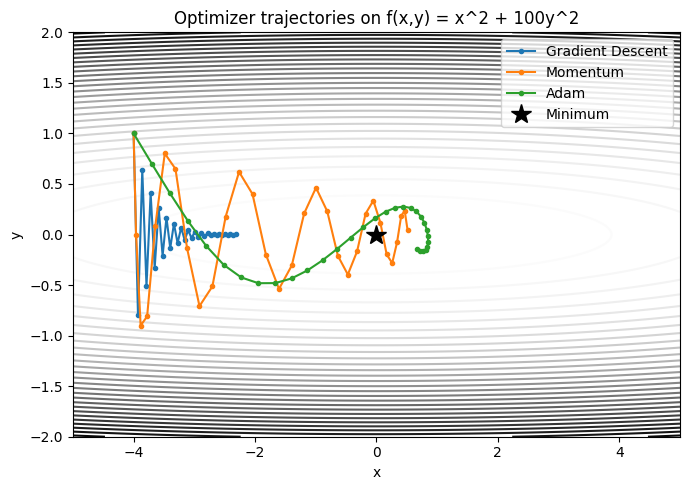

In [6]:
# Contour plot with all three trajectories overlaid
xs = np.linspace(-5, 5, 200)
ys = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(xs, ys)
Z = f(X, Y)

plt.figure(figsize=(7, 5))
plt.contour(X, Y, Z, levels=30, cmap="Greys")
plt.plot(path_gd[:, 0], path_gd[:, 1], "o-", label="Gradient Descent", markersize=3)
plt.plot(path_mom[:, 0], path_mom[:, 1], "o-", label="Momentum", markersize=3)
plt.plot(path_adam[:, 0], path_adam[:, 1], "o-", label="Adam", markersize=3)
plt.plot(0, 0, "k*", markersize=15, label="Minimum")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Optimizer trajectories on f(x,y) = x^2 + 100y^2")
plt.legend()
plt.tight_layout()
plt.show()

**Q5.1** Describe the main differences you observe among the optimization trajectories of Gradient Descent, Momentum, and Adam.

**Q5.2** Does plain gradient descent oscillate in the $y$ direction, the $x$
direction, or both? Relate this to the fact that the surface is much steeper in $y$
than in $x$.


## Answers

### 5.1
Gradient descent zigzags sharply in the steep y direction while
progressing slowly in x. Momentum averages recent gradients,
which makes opposing gradients partially cancel and consistent
gradients to reinforce each other. Its trajectory crosses the valley
less frequently and advances farther in x. Adam then, on top of direction,
scales updates using recent gradients squared, reducing the difference
in update sizes between the two directions. The oscillations are even 
more spaced than with normal momentum.

### 5.2
The surface is much steeper in y, so the gradient makes updates large enough to overshoot y=0. In x, the smaller gradient makes slow progress toward zero without overshooting. Thus, it oscillates in y and not in x.

## Part 5 Training a Neural Network with Different Optimizers

We now train the classification network on the Breast Cancer Wisconsin dataset from Tuesday class (30 features, binary classification:
malignant vs. benign), using three different optimizers, and compare the loss curves.

In [7]:
# Load data
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("X shape:", X.shape)
print("\nClasses:")
print(dict(enumerate(data.target_names)))

X.head()

X shape: (569, 30)

Classes:
{0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
# scale the data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

# explicit to_numpy() as was erroring without it
y_train = torch.tensor(y_train.to_numpy(), dtype=torch.float32).reshape(
    -1, 1
)  # reshape to make column vector
y_test = torch.tensor(y_test.to_numpy(), dtype=torch.float32).reshape(
    -1, 1
)  # to use in loss function

In [11]:
class ClassificationNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(30, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
        )

    def forward(self, x):
        return self.network(x)

**Q6.1** The network architecture is $ 30 \rightarrow 16 \rightarrow 8 \rightarrow 1$, where each number represents the number of neurons in each layer. Calculate the total number of trainable parameters. What exactly is the optimizer optimizing in this neural network?

## Answers

### 6.1
$$
(30 \cdot 16 + 16) + (16 \cdot 8 + 8) + (8 \cdot 1 + 1)
= 496 + 136 + 9 = 641
$$

The optimizer adjusts all of these trainable weights and biases to minimize the training loss.

In [12]:
def train(optimizer_name, n_epochs=100, lr=0.01):
    torch.manual_seed(0)  # same initial weights every time
    model = ClassificationNN()
    loss_fn = nn.BCEWithLogitsLoss()

    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr)
    elif optimizer_name == "momentum":
        optimizer = optim.SGD(model.parameters(), lr, momentum=0.9)
    elif optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr)
    else:
        raise ValueError(optimizer_name)

    losses = []
    for _ in range(n_epochs):
        optimizer.zero_grad()
        pred = model(X_train)
        loss = loss_fn(pred, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return model, losses


results = {}
for name in ["sgd", "momentum", "adam"]:
    model, losses = train(name, n_epochs=100, lr=0.01)
    results[name] = (model, losses)

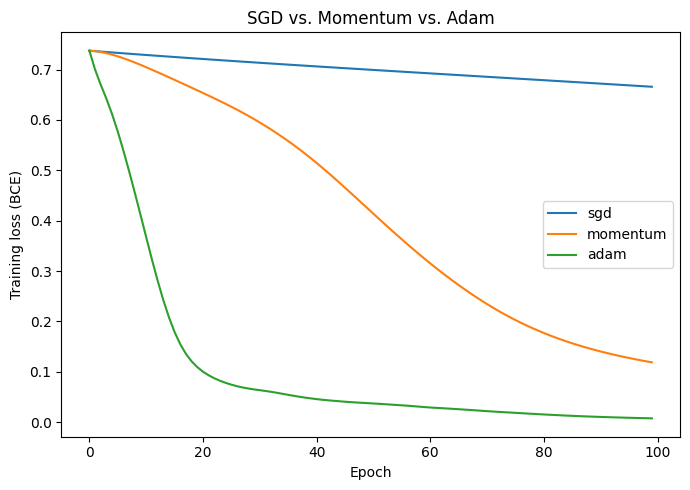

      sgd: final train loss = 0.6659, test accuracy = 0.5614
 momentum: final train loss = 0.1187, test accuracy = 0.9561
     adam: final train loss = 0.0075, test accuracy = 0.9561


In [13]:
plt.figure(figsize=(7, 5))
for name, (_, losses) in results.items():
    plt.plot(losses, label=name)
plt.xlabel("Epoch")
plt.ylabel("Training loss (BCE)")
plt.title("SGD vs. Momentum vs. Adam")
plt.legend()
plt.tight_layout()
plt.show()

for name, (model, losses) in results.items():
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_test))
        preds = (probs >= 0.5).float()
        acc = (preds == y_test).float().mean().item()
    print(f"{name:>9s}: final train loss = {losses[-1]:.4f}, test accuracy = {acc:.4f}")

**Q6.2** Which optimizer had the lowest training loss after 100 epochs? Which optimizer reduced the loss most rapidly during the early stages of training?

**Q6.3** All three optimizers used the same learning rate (`lr=0.01`). Is that a
completely fair comparison? What would you need to do to compare them more fairly?



## Answers

### 6.2
Both the optimizer that had the lowest training loss after 100 epochs and reduced the loss most rapidly during the early stages of training was Adam.

### 6.3
It's not a completely fair comparison because each optimizer uses the learning rate differently. So the current $lr=0.01$ may suit one of them better than the others.
If we wanted a truly fair comparison, we could tune each optimizer's learning rate with the validation data using a same number of trials and epochs per trial, and keeping all the other hyperparameters like network, initialization, split, etc. the same.
